## **AIVLE School 미니프로젝트 8기 AI트랙 1차** ##
## **공공데이터를 활용한 <span style="color:skyblue">미세먼지 농도</span> 예측**
---
## [step 1,2] 데이터 분석 및 전처리

## **0.프로젝트 소개**

### (1) 수행 목표
- 미세먼지 농도를 예측하는 머신러닝 모델을 만드세요.

#### 우리가 풀어야 하는 문제는 무엇인가요?
* 서울 지역의 미세먼지 데이터와 날씨 데이터를 활용하여, 미세먼지 예측에 관련 있는 데이터 항목으로 데이터를 구성, 전처리 하여 미세먼지 농도를 예측하는 머신러닝 모델 구현

### (2) 데이터 소개

#### 1) 기본 데이터

* 학습 데이터
    * air_2024.csv : 2024년 미세먼지 데이터
    * weather_2024.csv : 2024년 날씨 데이터
* 테스트 데이터
    * air_2025.csv : 2025년 미세먼지 데이터
    * weather_2025.csv : 2025년 날씨 데이터

#### 2) 데이터셋의 변수 소개(weather_202x)

* 증기압: 증기가 고체 또는 액체와 동적 평형 상태에 있을 때 증기의 압력 (증기가 되려는 힘)
* 이슬점 온도: 불포화 상태의 공기가 냉각될 때, 포화 상태에 도달하여 수증기의 응결이 시작되는 온도
* 일조: 일정한 물체나 땅의 겉면에 태양 광선이 비치는 시간 (1시간 중 비율)
* 일사(량): 태양으로부터 오는 태양 복사 에너지가 지표에 닿는 양 (면적당 에너지 량)
* 전운량: 하늘을 육안으로 관측하여 전부 구름일 때 10, 구름이 덮고 있는 하늘의 비율에 따라 0~10
* 중하층운량: 중층과 하층에 있는 구름의 분포량(중하층 구름이 날씨에 영향 주므로 따로 표기)
* 운형(운형약어): 구름의 종류. 약어 코드로 기재됨
* 최저운고: 가장 낮은 구름의 높이
* 현상번호(국내식): 비, 소낙비, 싸락눈, 눈보라 등의 기상현상을 나타낸 코드번호
* 지면온도: 지면 0cm 온도
* 지중온도: 땅 속 온도변수1

## **1.환경설정**

* 세부 요구사항
    - 경로 설정 : 프로젝트 폴더를 준비하고 데이터를 로딩하시오.
        * 구글코랩
            * 구글 드라이브에 project 폴더를 만들고,
            * 데이터 파일을 복사해 넣습니다.
        * (필요시) 로컬 수행(Ananconda)
            * 제공된 압축파일을 다운받아 압축을 풀고
            * anaconda의 root directory(보통 C:/Users/< ID > 에 project 폴더를 만들고, 복사해 넣습니다.
            
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.

### (1) 경로 설정
* 구글 코랩 (또는 필요시 로컬)를 사용하시면 됩니다.

#### 1) 구글 코랩 수행

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/KT AIVLE/project1/project1/'
# path = '/content/sample_data/'

#### 2) (희망시) 로컬 수행(Anaconda)
* project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [ ]:
# path = 'C:/Users/User/project/'

### (2) 라이브러리 설치 및 불러오기

#### 1) 라이브러리 설치 및 로딩

In [ ]:
# 필요한 라이브러리 설치 및 불러오기

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from statsmodels.graphics.mosaicplot import mosaic
from scipy import stats as spst
import statsmodels.api as sm
import joblib

# 더 필요한 라이브러리를 아래에 추가합니다.




> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
<small>(해결되지 않는다면 아래 Colab 한글 깨짐 현상 해결법 참고)<br>https://developnote.tistory.com/165#google_vignette </small>

In [ ]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

In [ ]:
# (Colab) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
!apt -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

import matplotlib as mpl
import matplotlib.font_manager as fm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

### (3) 데이터 불러오기
* Pandas 라이브러리를 활용해서 'air_2024.csv'파일을 'air_24' 변수에,'air_2025.csv'파일을 'air_25' 변수에 저장하고 그 데이터를 확인하세요.
 ( 구분자/인코딩 sep = ',',encoder = 'cp949')

* Pandas 라이브러리를 활용해서 'weather_2024.csv'파일을 'weather_24' 변수에,'weather_2025.csv'파일을 'weather_25' 변수에 저장하고 그 데이터를 확인하세요.
 ( 구분자/인코딩 sep = ',',encoder = 'cp949')

#### 1) 데이터로딩

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 데이터 로딩
air_24 = pd.read_csv(path + 'air_2024.csv', sep = ',', encoding = 'cp949')
air_25 = pd.read_csv(path + 'air_2025.csv', sep = ',', encoding = 'cp949')
weather_24 = pd.read_csv(path + 'weather_2024.csv', sep = ',', encoding = 'cp949')
weather_25 = pd.read_csv(path + 'weather_2025.csv', sep = ',', encoding = 'cp949')

air_24 = pd.DataFrame(air_24)
air_25 = pd.DataFrame(air_25)
weather_24 = pd.DataFrame(weather_24)
weather_25 = pd.DataFrame(weather_25)

air_24.head()

,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
0,서울 종로구,도시대기,111123,종로구,2024010101,0.0031,1.21,0.0022,0.0425,29.0,23.0,서울 종로구 종로35가길 19
1,서울 종로구,도시대기,111123,종로구,2024010102,0.0032,1.16,0.0020,0.0393,24.0,21.0,서울 종로구 종로35가길 19
2,서울 종로구,도시대기,111123,종로구,2024010103,0.0030,1.00,0.0022,0.0359,23.0,19.0,서울 종로구 종로35가길 19
3,서울 종로구,도시대기,111123,종로구,2024010104,0.0029,0.98,0.0021,0.0355,23.0,18.0,서울 종로구 종로35가길 19
4,서울 종로구,도시대기,111123,종로구,2024010105,0.0031,1.02,0.0020,0.0371,25.0,21.0,서울 종로구 종로35가길 19


#### 2) 기본 정보 조회
- 데이터를 head, tail. describe, info 등을 활용하여 확인하세요.

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
air_24.head()

,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
0,서울 종로구,도시대기,111123,종로구,2024010101,0.0031,1.21,0.0022,0.0425,29.0,23.0,서울 종로구 종로35가길 19
1,서울 종로구,도시대기,111123,종로구,2024010102,0.0032,1.16,0.0020,0.0393,24.0,21.0,서울 종로구 종로35가길 19
2,서울 종로구,도시대기,111123,종로구,2024010103,0.0030,1.00,0.0022,0.0359,23.0,19.0,서울 종로구 종로35가길 19
3,서울 종로구,도시대기,111123,종로구,2024010104,0.0029,0.98,0.0021,0.0355,23.0,18.0,서울 종로구 종로35가길 19
4,서울 종로구,도시대기,111123,종로구,2024010105,0.0031,1.02,0.0020,0.0371,25.0,21.0,서울 종로구 종로35가길 19


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
air_24.tail()

,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
8779,서울 종로구,도시대기,111123,종로구,2024123120,0.0027,0.36,0.0284,0.0166,25.0,14.0,서울 종로구 종로35가길 19
8780,서울 종로구,도시대기,111123,종로구,2024123121,0.0026,0.36,0.0257,0.0187,23.0,12.0,서울 종로구 종로35가길 19
8781,서울 종로구,도시대기,111123,종로구,2024123122,0.0026,0.40,0.0204,0.0238,19.0,12.0,서울 종로구 종로35가길 19
8782,서울 종로구,도시대기,111123,종로구,2024123123,0.0023,0.48,0.0135,0.0314,21.0,13.0,서울 종로구 종로35가길 19
8783,서울 종로구,도시대기,111123,종로구,2024123124,0.0024,0.56,0.0067,0.0403,22.0,11.0,서울 종로구 종로35가길 19


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
air_24.describe()

,측정소코드,측정일시,SO2,CO,O3,NO2,PM10,PM25
count,8784.0,8.784000e+03,8591.000000,8684.000000,8661.000000,8665.000000,8649.000000,8658.000000
mean,111123.0,2.024067e+09,0.002956,0.412198,0.034355,0.019635,30.660308,18.975629
std,0.0,3.453123e+04,0.000670,0.169987,0.021484,0.013290,24.811649,13.612901
min,111123.0,2.024010e+09,0.001500,0.100000,0.001300,0.002800,3.000000,1.000000
25%,111123.0,2.024040e+09,0.002500,0.300000,0.020400,0.010500,17.000000,10.000000
50%,111123.0,2.024070e+09,0.002800,0.370000,0.031500,0.015800,26.000000,16.000000
75%,111123.0,2.024100e+09,0.003300,0.480000,0.044600,0.024300,38.000000,25.000000
max,111123.0,2.024123e+09,0.007600,1.560000,0.177300,0.106400,442.000000,96.000000


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
air_24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역      8784 non-null   object 
 1   망       8784 non-null   object 
 2   측정소코드   8784 non-null   int64  
 3   측정소명    8784 non-null   object 
 4   측정일시    8784 non-null   int64  
 5   SO2     8591 non-null   float64
 6   CO      8684 non-null   float64
 7   O3      8661 non-null   float64
 8   NO2     8665 non-null   float64
 9   PM10    8649 non-null   float64
 10  PM25    8658 non-null   float64
 11  주소      8784 non-null   object 
dtypes: float64(6), int64(2), object(4)
memory usage: 823.6+ KB


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
weather_24.head()

,지점,지점명,일시,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
0,108,서울,2024-01-01 0:00,0.6,NaN,NaN,9.0,1.9,NaN,20.0,...,NaN,394,NaN,19.0,-0.2,NaN,-0.1,-0.2,0.0,1.0
1,108,서울,2024-01-01 1:00,0.5,NaN,NaN,NaN,2.2,NaN,50.0,...,NaN,402,NaN,19.0,-0.2,NaN,-0.1,-0.2,0.0,1.0
2,108,서울,2024-01-01 2:00,0.4,NaN,NaN,NaN,0.4,NaN,0.0,...,13.0,616,NaN,19.0,-0.3,NaN,-0.1,-0.2,0.0,1.0
3,108,서울,2024-01-01 3:00,-0.1,NaN,NaN,NaN,1.7,NaN,20.0,...,13.0,265,NaN,19.0,-0.3,NaN,-0.1,-0.2,0.0,1.0
4,108,서울,2024-01-01 4:00,-0.2,NaN,NaN,NaN,2.2,NaN,20.0,...,14.0,203,NaN,19.0,-0.3,NaN,-0.1,-0.2,0.0,1.0


In [ ]:
weather_24.tail()

,지점,지점명,일시,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
8779,108,서울,2024-12-31 19:00,0.5,NaN,NaN,9.0,1.9,NaN,270.0,...,NaN,3760,NaN,NaN,-0.6,NaN,-0.2,-0.3,0.9,1.7
8780,108,서울,2024-12-31 20:00,0.0,NaN,NaN,9.0,2.4,NaN,250.0,...,NaN,3645,NaN,NaN,-0.9,NaN,-0.4,-0.3,0.9,1.7
8781,108,서울,2024-12-31 21:00,-0.7,NaN,NaN,9.0,1.0,NaN,270.0,...,NaN,3794,NaN,NaN,-1.3,NaN,-0.3,-0.3,0.9,1.7
8782,108,서울,2024-12-31 22:00,-1.0,NaN,NaN,9.0,0.7,NaN,320.0,...,NaN,3779,NaN,NaN,-1.9,NaN,-0.3,-0.3,0.9,1.7
8783,108,서울,2024-12-31 23:00,-1.4,NaN,NaN,9.0,1.3,NaN,250.0,...,NaN,3412,NaN,NaN,-2.6,NaN,-0.3,-0.3,0.9,1.7


In [ ]:
weather_24.describe()

,지점,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,습도(%),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
count,8784.0,8784.000000,0.0,956.000000,1732.0,8753.000000,13.0,8753.000000,13.0,8784.000000,...,4474.000000,8784.000000,0.0,2.403000e+03,8784.000000,14.0,8784.000000,8784.000000,8784.000000,8784.000000
mean,108.0,14.869331,NaN,1.371757,9.0,2.313150,9.0,177.166686,9.0,65.812045,...,14.318730,2326.851434,NaN,4.656389e+04,15.877630,0.0,14.839982,15.002482,14.773816,15.008322
std,0.0,10.903428,NaN,3.330638,0.0,1.129083,0.0,106.848304,0.0,17.543280,...,12.814185,1204.915094,NaN,1.278100e+06,13.397386,0.0,10.362239,10.573520,9.897558,9.514987
min,108.0,-14.000000,NaN,0.000000,9.0,0.000000,9.0,0.000000,9.0,14.000000,...,2.000000,24.000000,NaN,1.000000e+00,-8.400000,0.0,-2.400000,-1.700000,-0.500000,0.300000
25%,108.0,4.700000,NaN,0.000000,9.0,1.500000,9.0,50.000000,9.0,53.000000,...,7.000000,1357.000000,NaN,4.000000e+00,2.900000,0.0,4.300000,4.200000,4.700000,5.000000
50%,108.0,15.900000,NaN,0.100000,9.0,2.200000,9.0,200.000000,9.0,67.000000,...,10.000000,2290.000000,NaN,1.900000e+01,15.600000,0.0,16.500000,16.400000,16.200000,16.400000
75%,108.0,24.400000,NaN,1.100000,9.0,3.000000,9.0,270.000000,9.0,80.000000,...,15.000000,3220.250000,NaN,4.200000e+01,25.400000,0.0,24.500000,25.000000,24.200000,24.200000
max,108.0,36.300000,NaN,39.000000,9.0,7.500000,9.0,360.000000,9.0,100.000000,...,75.000000,5000.000000,NaN,4.219020e+07,61.200000,0.0,32.700000,32.500000,31.100000,29.700000


In [ ]:
weather_24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   지점             8784 non-null   int64  
 1   지점명            8784 non-null   object 
 2   일시             8784 non-null   object 
 3   기온(°C)         8784 non-null   float64
 4   기온 QC플래그       0 non-null      float64
 5   강수량(mm)        956 non-null    float64
 6   강수량 QC플래그      1732 non-null   float64
 7   풍속(m/s)        8753 non-null   float64
 8   풍속 QC플래그       13 non-null     float64
 9   풍향(16방위)       8753 non-null   float64
 10  풍향 QC플래그       13 non-null     float64
 11  습도(%)          8784 non-null   int64  
 12  습도 QC플래그       0 non-null      float64
 13  증기압(hPa)       8784 non-null   float64
 14  이슬점온도(°C)      8784 non-null   float64
 15  현지기압(hPa)      8784 non-null   float64
 16  현지기압 QC플래그     0 non-null      float64
 17  해면기압(hPa)      8784 non-null   float64
 18  해면기압 QC플

## **2.EDA 1단계 - 데이터 기본 탐색 및 분석**

* 단변량 분석은 데이터분석의 매우 기초적인 분석기법으로, 독립적인 개별 변수가 가지고있는 특성들을 이해하는 과정입니다.

    * <span style="color: green"> 4 ~ 5개 변수를 뽑아 확인해보세요 </span>
    * <span style="color: green"> 개별 변수에 대해 아래 사항들을 분석해보세요. </span>

        - 변수가 수치형인지, 범주형인지
        - 결측치 존재 여부 및 조치 방안
        - 기초 통계량 확인
        - 데이터 분포 확인
        - 변수가 내포하고 있는 의미 파악을 위한 추가 분석
        - 위 정보로부터 파악한 내용 정리


### (1) 변수1 : 측정일시

In [ ]:
# 변수가 수치형인지, 범주형인지 확인해 보세요
air_24.dtypes

,0
지역,object
망,object
측정소코드,int64
측정소명,object
측정일시,int64
SO2,float64
CO,float64
O3,float64
NO2,float64
PM10,float64


In [ ]:
# 결측치 존재 여부를 확인하고 조치 방안을 검토해 보세요
air_24.isnull().sum()

,0
지역,0
망,0
측정소코드,0
측정소명,0
측정일시,0
SO2,193
CO,100
O3,123
NO2,119
PM10,135


In [ ]:
# 기초 통계량을 확인해 보세요
air_24.describe()

,측정소코드,측정일시,SO2,CO,O3,NO2,PM10,PM25
count,8784.0,8.784000e+03,8591.000000,8684.000000,8661.000000,8665.000000,8649.000000,8658.000000
mean,111123.0,2.024067e+09,0.002956,0.412198,0.034355,0.019635,30.660308,18.975629
std,0.0,3.453123e+04,0.000670,0.169987,0.021484,0.013290,24.811649,13.612901
min,111123.0,2.024010e+09,0.001500,0.100000,0.001300,0.002800,3.000000,1.000000
25%,111123.0,2.024040e+09,0.002500,0.300000,0.020400,0.010500,17.000000,10.000000
50%,111123.0,2.024070e+09,0.002800,0.370000,0.031500,0.015800,26.000000,16.000000
75%,111123.0,2.024100e+09,0.003300,0.480000,0.044600,0.024300,38.000000,25.000000
max,111123.0,2.024123e+09,0.007600,1.560000,0.177300,0.106400,442.000000,96.000000


<Axes: xlabel='PM25', ylabel='PM10'>

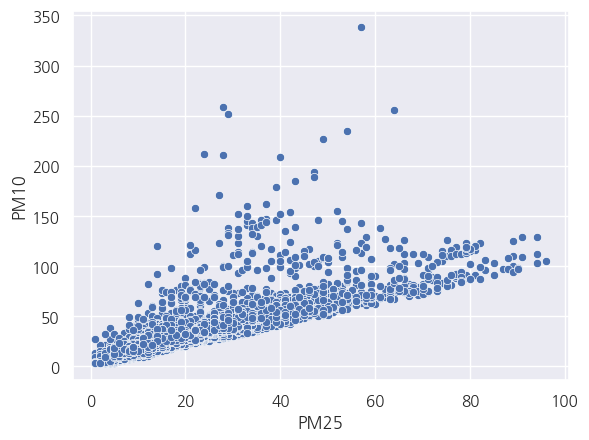

In [ ]:
# 데이터 분포를 시각해 보세요
sns.scatterplot(data = air_24, x = 'PM25', y = 'PM10')

<Axes: xlabel='SO2', ylabel='PM25'>

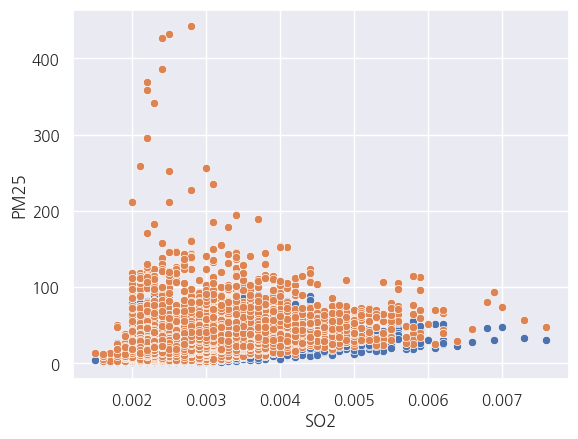

In [ ]:
sns.scatterplot(data = air_24, x = 'SO2', y = 'PM25')
sns.scatterplot(data = air_24, x = 'SO2', y = 'PM10')

<Axes: xlabel='CO', ylabel='PM25'>

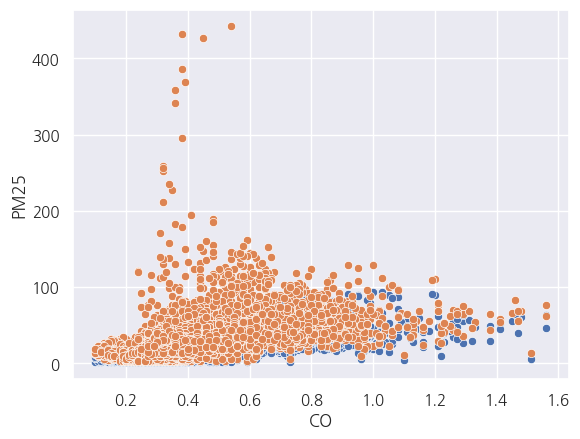

In [ ]:
sns.scatterplot(data = air_24, x = 'CO', y = 'PM25')
sns.scatterplot(data = air_24, x = 'CO', y = 'PM10')

<Axes: xlabel='O3', ylabel='PM25'>

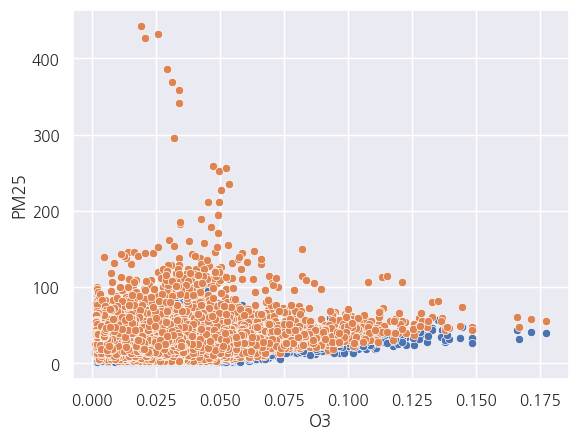

In [ ]:
sns.scatterplot(data = air_24, x = 'O3', y = 'PM25')
sns.scatterplot(data = air_24, x = 'O3', y = 'PM10')

<Axes: xlabel='NO2', ylabel='PM25'>

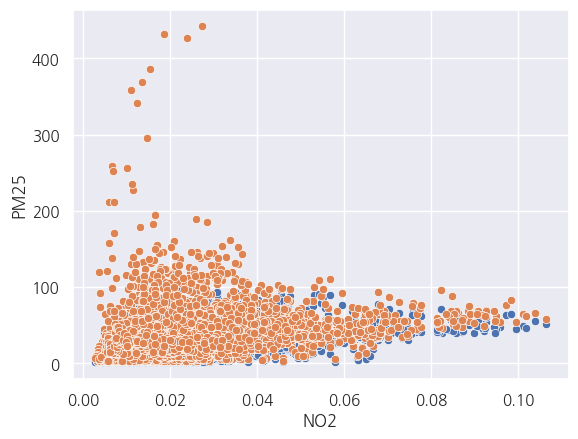

In [ ]:
sns.scatterplot(data = air_24, x = 'NO2', y = 'PM25')
sns.scatterplot(data = air_24, x = 'NO2', y = 'PM10')

In [ ]:
# 변수가 내포하고 있는 의미 파악을 위한 추가 분석
air_24.corr(numeric_only=True)

,측정소코드,측정일시,SO2,CO,O3,NO2,PM10,PM25
측정소코드,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
측정일시,NaN,1.000000,0.134738,-0.205040,-0.092987,-0.197702,-0.213265,-0.263131
SO2,NaN,0.134738,1.000000,0.395178,0.140590,0.350770,0.311610,0.386764
CO,NaN,-0.205040,0.395178,1.000000,-0.327778,0.848416,0.469536,0.698869
O3,NaN,-0.092987,0.140590,-0.327778,1.000000,-0.468983,0.089095,0.051118
NO2,NaN,-0.197702,0.350770,0.848416,-0.468983,1.000000,0.320453,0.496776
PM10,NaN,-0.213265,0.311610,0.469536,0.089095,0.320453,1.000000,0.826018
PM25,NaN,-0.263131,0.386764,0.698869,0.051118,0.496776,0.826018,1.000000


In [ ]:
# 위 정보로부터 파악한 내용을 서술해 보세요



미세먼지 농도 예측 (PM10, PM25 예측)
1. CO - 미세먼지: 0.46, 0.69 -> 상관관계 차이가 있음
2. O3 - 미세먼지: 0.08, 0.05 -> 상관관계 차이가 거의 없음
3. NO2 - 미세먼지: 0.32, 0.49 -> 상관관계 차이가 약간 있음
4. SO2 - 미세먼지: 0.31, 0.38 -> 상관관계 차이가 약간 있음



### (2) 변수2

In [ ]:
# 변수가 수치형인지, 범주형인지 확인해 보세요
weather_24.dtypes

,0
지점,int64
지점명,object
일시,object
기온(°C),float64
기온 QC플래그,float64
강수량(mm),float64
강수량 QC플래그,float64
풍속(m/s),float64
풍속 QC플래그,float64
풍향(16방위),float64


In [ ]:
# 결측치 존재 여부를 확인하고 조치 방안을 검토해 보세요
weather_24.isnull().sum()

,0
지점,0
지점명,0
일시,0
기온(°C),0
기온 QC플래그,8784
강수량(mm),7828
강수량 QC플래그,7052
풍속(m/s),31
풍속 QC플래그,8771
풍향(16방위),31


In [ ]:
# 기초 통계량을 확인해 보세요
weather_24.describe()

,지점,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,습도(%),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
count,8784.0,8784.000000,0.0,956.000000,1732.0,8753.000000,13.0,8753.000000,13.0,8784.000000,...,4474.000000,8784.000000,0.0,2.403000e+03,8784.000000,14.0,8784.000000,8784.000000,8784.000000,8784.000000
mean,108.0,14.869331,NaN,1.371757,9.0,2.313150,9.0,177.166686,9.0,65.812045,...,14.318730,2326.851434,NaN,4.656389e+04,15.877630,0.0,14.839982,15.002482,14.773816,15.008322
std,0.0,10.903428,NaN,3.330638,0.0,1.129083,0.0,106.848304,0.0,17.543280,...,12.814185,1204.915094,NaN,1.278100e+06,13.397386,0.0,10.362239,10.573520,9.897558,9.514987
min,108.0,-14.000000,NaN,0.000000,9.0,0.000000,9.0,0.000000,9.0,14.000000,...,2.000000,24.000000,NaN,1.000000e+00,-8.400000,0.0,-2.400000,-1.700000,-0.500000,0.300000
25%,108.0,4.700000,NaN,0.000000,9.0,1.500000,9.0,50.000000,9.0,53.000000,...,7.000000,1357.000000,NaN,4.000000e+00,2.900000,0.0,4.300000,4.200000,4.700000,5.000000
50%,108.0,15.900000,NaN,0.100000,9.0,2.200000,9.0,200.000000,9.0,67.000000,...,10.000000,2290.000000,NaN,1.900000e+01,15.600000,0.0,16.500000,16.400000,16.200000,16.400000
75%,108.0,24.400000,NaN,1.100000,9.0,3.000000,9.0,270.000000,9.0,80.000000,...,15.000000,3220.250000,NaN,4.200000e+01,25.400000,0.0,24.500000,25.000000,24.200000,24.200000
max,108.0,36.300000,NaN,39.000000,9.0,7.500000,9.0,360.000000,9.0,100.000000,...,75.000000,5000.000000,NaN,4.219020e+07,61.200000,0.0,32.700000,32.500000,31.100000,29.700000


<Axes: xlabel='기온(°C)', ylabel='강수량(mm)'>

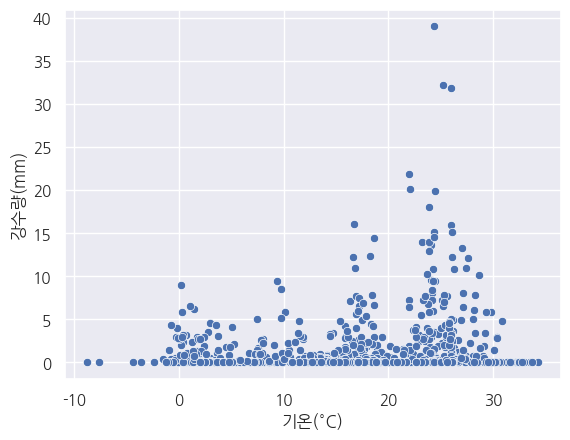

In [ ]:
# 데이터 분포를 시각해 보세요
sns.scatterplot(data = weather_24, x = '기온(°C)', y = '강수량(mm)')

<Axes: xlabel='강수량(mm)', ylabel='3시간신적설(cm)'>

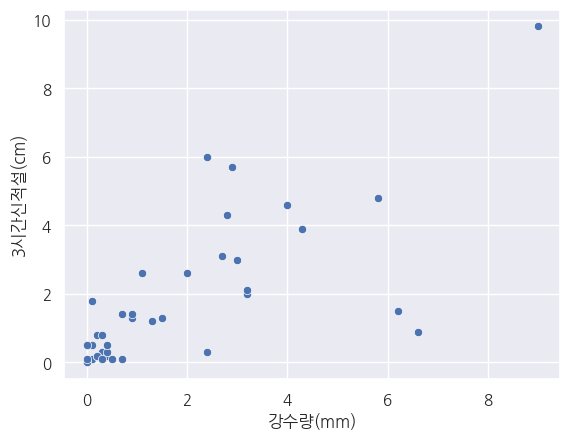

In [ ]:
sns.scatterplot(data = weather_24, x = '강수량(mm)', y = '3시간신적설(cm)')

In [ ]:
# 변수가 내포하고 있는 의미 파악을 위한 추가 분석
weather_24.corr(numeric_only=True)

,지점,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,습도(%),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
지점,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
기온(°C),NaN,1.000000,NaN,0.077718,NaN,0.024727,NaN,-0.052728,NaN,0.058035,...,-0.094798,0.022681,NaN,-0.015412,0.926813,NaN,0.962969,0.957948,0.938200,0.927086
기온 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
강수량(mm),NaN,0.077718,NaN,1.000000,NaN,0.041658,NaN,-0.013825,NaN,0.295623,...,-0.220309,-0.261918,NaN,-0.012749,0.068125,NaN,0.091485,0.097525,0.103959,0.108554
강수량 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
풍속(m/s),NaN,0.024727,NaN,0.041658,NaN,1.000000,NaN,0.066361,NaN,-0.162341,...,-0.164231,0.214409,NaN,0.025412,0.083806,NaN,0.000499,-0.011847,-0.033962,-0.044077
풍속 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
풍향(16방위),NaN,-0.052728,NaN,-0.013825,NaN,0.066361,NaN,1.000000,NaN,-0.204781,...,-0.061746,-0.069929,NaN,0.024252,-0.014126,NaN,-0.033262,-0.040497,-0.054309,-0.067119
풍향 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
습도(%),NaN,0.058035,NaN,0.295623,NaN,-0.162341,NaN,-0.204781,NaN,1.000000,...,-0.348713,-0.491919,NaN,0.040245,-0.082024,NaN,0.131298,0.158820,0.185844,0.202024


In [ ]:
# 위 정보로부터 파악한 내용을 서술해 보세요


- 결측치가 많아서, 전처리 규칙을 잘 세워야 겠다.

### (3) 변수3

In [ ]:
# 변수가 수치형인지, 범주형인지 확인해 보세요
air_25.dtypes

,0
지역,object
망,object
측정소코드,int64
측정소명,object
측정일시,int64
SO2,float64
CO,float64
O3,float64
NO2,float64
PM10,float64


In [ ]:
# 결측치 존재 여부를 확인하고 조치 방안을 검토해 보세요
air_25.isnull().sum()

,0
지역,0
망,0
측정소코드,0
측정소명,0
측정일시,0
SO2,25
CO,25
O3,25
NO2,25
PM10,27


In [ ]:
# 기초 통계량을 확인해 보세요
air_25.describe()

,측정소코드,측정일시,SO2,CO,O3,NO2,PM10,PM25
count,2880.0,2.880000e+03,2855.000000,2855.000000,2855.000000,2855.000000,2853.000000,2848.000000
mean,111123.0,2.025027e+09,0.002730,0.468186,0.033284,0.023588,45.134946,27.939256
std,0.0,1.128904e+04,0.000736,0.187644,0.018110,0.014659,27.478036,18.991989
min,111123.0,2.025010e+09,0.001300,0.210000,0.001500,0.004800,3.000000,1.000000
25%,111123.0,2.025013e+09,0.002200,0.340000,0.020850,0.012100,26.000000,14.000000
50%,111123.0,2.025030e+09,0.002600,0.410000,0.034000,0.018800,40.000000,23.000000
75%,111123.0,2.025035e+09,0.003200,0.560000,0.044350,0.031700,57.000000,36.000000
max,111123.0,2.025043e+09,0.007600,1.750000,0.090200,0.082700,271.000000,129.000000


<Axes: xlabel='PM25', ylabel='PM10'>

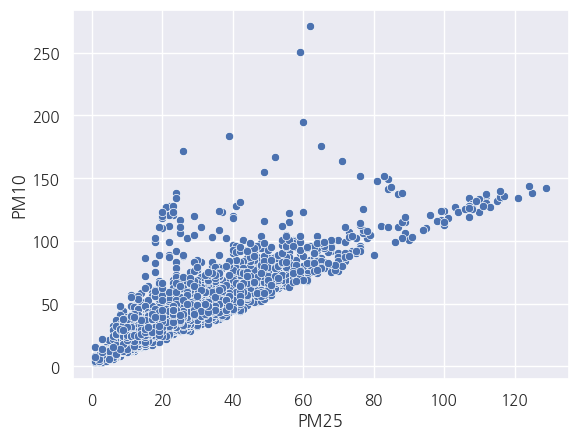

In [ ]:
# 데이터 분포를 시각해 보세요
sns.scatterplot(data = air_25, x = 'PM25', y = 'PM10')

In [ ]:
# 변수가 내포하고 있는 의미 파악을 위한 추가 분석
air_25.corr(numeric_only=True)

,측정소코드,측정일시,SO2,CO,O3,NO2,PM10,PM25
측정소코드,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
측정일시,NaN,1.000000,0.033739,-0.293302,0.548635,-0.202502,0.070988,-0.092685
SO2,NaN,0.033739,1.000000,0.469633,0.032124,0.433478,0.552965,0.517535
CO,NaN,-0.293302,0.469633,1.000000,-0.612013,0.885123,0.497440,0.683095
O3,NaN,0.548635,0.032124,-0.612013,1.000000,-0.697880,0.063036,-0.132779
NO2,NaN,-0.202502,0.433478,0.885123,-0.697880,1.000000,0.349102,0.494477
PM10,NaN,0.070988,0.552965,0.497440,0.063036,0.349102,1.000000,0.832289
PM25,NaN,-0.092685,0.517535,0.683095,-0.132779,0.494477,0.832289,1.000000


In [ ]:
# 위 정보로부터 파악한 내용을 서술해 보세요


### PM10이 PM25와 강한 상관관계를 가지는 것을 볼 수 있습니다

### (4) 변수4

In [ ]:
# 변수가 수치형인지, 범주형인지 확인해 보세요
weather_25.dtypes

,0
지점,int64
지점명,object
일시,object
기온(°C),float64
기온 QC플래그,float64
강수량(mm),float64
강수량 QC플래그,float64
풍속(m/s),float64
풍속 QC플래그,float64
풍향(16방위),int64


In [ ]:
# 결측치 존재 여부를 확인하고 조치 방안을 검토해 보세요.
weather_25.isnull().sum()

,0
지점,0
지점명,0
일시,0
기온(°C),0
기온 QC플래그,3600
강수량(mm),3260
강수량 QC플래그,2951
풍속(m/s),0
풍속 QC플래그,3600
풍향(16방위),0


In [ ]:
# 기초 통계량을 확인해 보세요
weather_25.describe()

,지점,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,습도(%),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
count,3600.0,3600.000000,0.0,340.000000,649.0,3600.000000,0.0,3600.000000,0.0,3600.000000,...,1495.000000,3600.000000,0.0,1.084000e+03,3600.000000,0.0,3600.000000,3600.000000,3600.000000,3600.000000
mean,108.0,7.537972,NaN,0.826765,9.0,2.510083,NaN,197.808333,NaN,60.103333,...,14.435452,2120.552500,NaN,2.367251e+04,8.194944,NaN,7.234694,6.744056,6.601917,6.605361
std,0.0,8.975582,NaN,1.581331,0.0,1.249238,NaN,100.498352,NaN,19.250961,...,13.834592,1212.132264,NaN,5.830631e+05,10.801505,NaN,8.041682,7.778889,6.896935,6.331297
min,108.0,-12.100000,NaN,0.000000,9.0,0.000000,NaN,0.000000,NaN,13.000000,...,1.000000,51.000000,NaN,1.000000e+00,-8.500000,NaN,-3.600000,-3.900000,-1.700000,-0.700000
25%,108.0,0.800000,NaN,0.000000,9.0,1.600000,NaN,70.000000,NaN,45.000000,...,6.000000,1123.750000,NaN,5.000000e+00,-0.400000,NaN,-0.400000,-0.600000,-0.300000,0.400000
50%,108.0,7.000000,NaN,0.150000,9.0,2.300000,NaN,250.000000,NaN,59.000000,...,10.000000,2033.500000,NaN,1.900000e+01,6.050000,NaN,6.500000,5.900000,6.200000,5.900000
75%,108.0,14.600000,NaN,0.900000,9.0,3.200000,NaN,270.000000,NaN,75.000000,...,16.000000,3057.250000,NaN,4.000000e+01,14.700000,NaN,14.100000,13.700000,13.500000,13.100000
max,108.0,30.300000,NaN,13.000000,9.0,8.400000,NaN,360.000000,NaN,98.000000,...,76.000000,5000.000000,NaN,1.916020e+07,46.700000,NaN,26.500000,25.400000,22.400000,20.800000


<Axes: xlabel='기온(°C)', ylabel='강수량(mm)'>

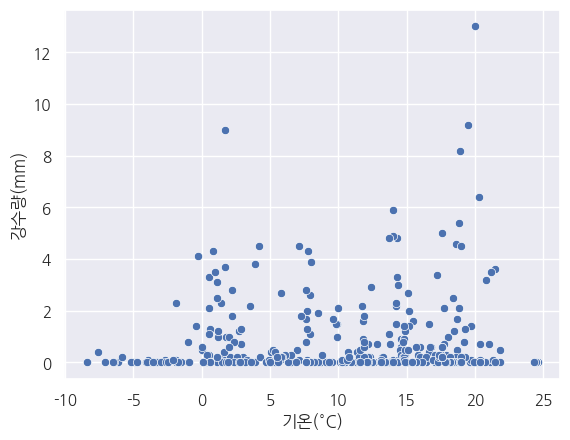

In [ ]:
# 데이터 분포를 시각해 보세요
sns.scatterplot(data = weather_25, x = '기온(°C)', y = '강수량(mm)')

In [ ]:
# 변수가 내포하고 있는 의미 파악을 위한 추가 분석
weather_25.corr(numeric_only=True)

,지점,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,습도(%),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
지점,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
기온(°C),NaN,1.000000,NaN,0.093195,NaN,0.050877,NaN,-0.073794,NaN,-0.073062,...,0.135984,-0.197159,NaN,0.038189,0.903899,NaN,0.913164,0.906666,0.841288,0.820727
기온 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
강수량(mm),NaN,0.093195,NaN,1.000000,NaN,-0.046109,NaN,-0.175955,NaN,0.323840,...,-0.243119,-0.226629,NaN,-0.021749,0.085020,NaN,0.105218,0.098146,0.089096,0.085284
강수량 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
풍속(m/s),NaN,0.050877,NaN,-0.046109,NaN,1.000000,NaN,0.150078,NaN,-0.282010,...,-0.050478,0.247901,NaN,-0.008687,0.176338,NaN,0.036557,0.028977,-0.028163,-0.032730
풍속 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
풍향(16방위),NaN,-0.073794,NaN,-0.175955,NaN,0.150078,NaN,1.000000,NaN,-0.242184,...,-0.022128,0.153392,NaN,-0.045096,-0.002249,NaN,-0.002842,-0.003287,-0.023305,-0.035562
풍향 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
습도(%),NaN,-0.073062,NaN,0.323840,NaN,-0.282010,NaN,-0.242184,NaN,1.000000,...,-0.463379,-0.575636,NaN,0.032840,-0.198093,NaN,0.010745,0.025287,0.095187,0.111434


In [ ]:
# 위 정보로부터 파악한 내용을 서술해 보세요

## **3.EDA 2단계 - 데이터 전처리**
- 진행한 개별 변수 분석에 맞추어 데이터를 전처리 하겠습니다.

### (1) air_24, air_25, weather_24, weather_25 데이터 전처리
* air_24, air_25 각각 '측정일시'를 활용하여 'time'변수 생성
    * 참고: 미세먼지 데이터는 1시-24시, 날씨 데이터는 0시-23시로 구성되어 있습니다. [2-3]에서 미세먼지와 날씨 데이터를 time 기준으로 합치려면 기준이 동일해야 합니다. 미세먼지 데이터에서 time 변수 생성 시 이를 미리 고려(예: air_24['측정일시'] -1)하세요.
* time 변수를 pd.to_datetime으로 데이터 타입 변경
    * 참고: format = '%Y%m%d%H'

#### **1) air_24, air_25 의 '측정일시'를 활용하여 'time' 변수 생성**

In [ ]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
air_24['time'] = air_24['측정일시'] - 1
air_25['time'] = air_25['측정일시'] - 1

air_24['time'] = pd.to_datetime(air_24['time'], format = '%Y%m%d%H')
air_25['time'] = pd.to_datetime(air_25['time'], format = '%Y%m%d%H')

In [ ]:
# 결과확인
air_24['time']

,time
0,2024-01-01 00:00:00
1,2024-01-01 01:00:00
2,2024-01-01 02:00:00
3,2024-01-01 03:00:00
4,2024-01-01 04:00:00
...,...
8779,2024-12-31 19:00:00
8780,2024-12-31 20:00:00
8781,2024-12-31 21:00:00
8782,2024-12-31 22:00:00


#### **2) weather_24, weather_25 의 '일시'를 활용하여 'time' 변수 생성**
* weather_24, weather_25 의 '일시'를 활용하여 'time'변수 생성
* time 변수를 pd.to_datetime으로 데이터 타입 변경

In [ ]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
weather_24['time'] = weather_24['일시']
weather_25['time'] = weather_25['일시']

weather_24['time'] = pd.to_datetime(weather_24['time'], format = '%Y-%m-%d %H:%M')
weather_25['time'] = pd.to_datetime(weather_25['time'], format = '%Y-%m-%d %H:%M')

In [ ]:
# 결과확인
weather_24['time']

,time
0,2024-01-01 00:00:00
1,2024-01-01 01:00:00
2,2024-01-01 02:00:00
3,2024-01-01 03:00:00
4,2024-01-01 04:00:00
...,...
8779,2024-12-31 19:00:00
8780,2024-12-31 20:00:00
8781,2024-12-31 21:00:00
8782,2024-12-31 22:00:00


#### **3) 'time' 기준으로 데이터 합치기**
* 미세먼지 데이터와 날씨 데이터를 'time' 기준으로 합쳐보세요.
    * df_24에는 'time' 기준으로 24년도 미세먼지, 날씨 데이터를 합쳐보세요.
    * df_25에는 'time' 기준으로 25년도 미세먼지, 날씨 데이터를 합쳐보세요.

In [ ]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
df_24 = pd.merge(air_24, weather_24, on = 'time')
df_25 = pd.merge(air_25, weather_25, on = 'time')

In [ ]:
# 결과확인
df_24.head()

,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
0,서울 종로구,도시대기,111123,종로구,2024010101,0.0031,1.21,0.0022,0.0425,29.0,...,NaN,394,NaN,19.0,-0.2,NaN,-0.1,-0.2,0.0,1.0
1,서울 종로구,도시대기,111123,종로구,2024010102,0.0032,1.16,0.0020,0.0393,24.0,...,NaN,402,NaN,19.0,-0.2,NaN,-0.1,-0.2,0.0,1.0
2,서울 종로구,도시대기,111123,종로구,2024010103,0.0030,1.00,0.0022,0.0359,23.0,...,13.0,616,NaN,19.0,-0.3,NaN,-0.1,-0.2,0.0,1.0
3,서울 종로구,도시대기,111123,종로구,2024010104,0.0029,0.98,0.0021,0.0355,23.0,...,13.0,265,NaN,19.0,-0.3,NaN,-0.1,-0.2,0.0,1.0
4,서울 종로구,도시대기,111123,종로구,2024010105,0.0031,1.02,0.0020,0.0371,25.0,...,14.0,203,NaN,19.0,-0.3,NaN,-0.1,-0.2,0.0,1.0


#### **4) 사용하지 않을 변수 제거**

* 머신러닝에 사용하지 않을 변수들을 제거해줍니다.
    * df_24, df_25에 사용할 변수들만 넣어보세요.
* time 변수를 기준으로 오름차순으로 정렬하세요

In [ ]:
df_24.columns

Index(['지역', '망', '측정소코드', '측정소명', '측정일시', 'SO2', 'CO', 'O3', 'NO2', 'PM10',
       'PM25', '주소', 'time', '지점', '지점명', '일시', '기온(°C)', '기온 QC플래그',
       '강수량(mm)', '강수량 QC플래그', '풍속(m/s)', '풍속 QC플래그', '풍향(16방위)', '풍향 QC플래그',
       '습도(%)', '습도 QC플래그', '증기압(hPa)', '이슬점온도(°C)', '현지기압(hPa)', '현지기압 QC플래그',
       '해면기압(hPa)', '해면기압 QC플래그', '일조(hr)', '일조 QC플래그', '일사(MJ/m2)',
       '일사 QC플래그', '적설(cm)', '3시간신적설(cm)', '전운량(10분위)', '중하층운량(10분위)',
       '운형(운형약어)', '최저운고(100m )', '시정(10m)', '지면상태(지면상태코드)', '현상번호(국내식)',
       '지면온도(°C)', '지면온도 QC플래그', '5cm 지중온도(°C)', '10cm 지중온도(°C)',
       '20cm 지중온도(°C)', '30cm 지중온도(°C)'],
      dtype='object')

In [ ]:
weather_24.corr(numeric_only=True)

,지점,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,습도(%),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
지점,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
기온(°C),NaN,1.000000,NaN,0.077718,NaN,0.024727,NaN,-0.052728,NaN,0.058035,...,-0.094798,0.022681,NaN,-0.015412,0.926813,NaN,0.962969,0.957948,0.938200,0.927086
기온 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
강수량(mm),NaN,0.077718,NaN,1.000000,NaN,0.041658,NaN,-0.013825,NaN,0.295623,...,-0.220309,-0.261918,NaN,-0.012749,0.068125,NaN,0.091485,0.097525,0.103959,0.108554
강수량 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
풍속(m/s),NaN,0.024727,NaN,0.041658,NaN,1.000000,NaN,0.066361,NaN,-0.162341,...,-0.164231,0.214409,NaN,0.025412,0.083806,NaN,0.000499,-0.011847,-0.033962,-0.044077
풍속 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
풍향(16방위),NaN,-0.052728,NaN,-0.013825,NaN,0.066361,NaN,1.000000,NaN,-0.204781,...,-0.061746,-0.069929,NaN,0.024252,-0.014126,NaN,-0.033262,-0.040497,-0.054309,-0.067119
풍향 QC플래그,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
습도(%),NaN,0.058035,NaN,0.295623,NaN,-0.162341,NaN,-0.204781,NaN,1.000000,...,-0.348713,-0.491919,NaN,0.040245,-0.082024,NaN,0.131298,0.158820,0.185844,0.202024


In [ ]:
# df_24, df_25에 사용할 변수들만 할당

cols = ['CO', 'NO2', 'SO2', 'PM10', 'PM25', 'time', '기온(°C)', '풍속(m/s)', '습도(%)', '전운량(10분위)', '중하층운량(10분위)']
df_24 = df_24[cols]
df_25 = df_25[cols]

df_24.head()

,CO,NO2,SO2,PM10,PM25,time,기온(°C),풍속(m/s),습도(%),전운량(10분위),중하층운량(10분위)
0,1.21,0.0425,0.0031,29.0,23.0,2024-01-01 00:00:00,0.6,1.9,97,0,0
1,1.16,0.0393,0.0032,24.0,21.0,2024-01-01 01:00:00,0.5,2.2,97,0,0
2,1.00,0.0359,0.0030,23.0,19.0,2024-01-01 02:00:00,0.4,0.4,98,6,2
3,0.98,0.0355,0.0029,23.0,18.0,2024-01-01 03:00:00,-0.1,1.7,98,1,1
4,1.02,0.0371,0.0031,25.0,21.0,2024-01-01 04:00:00,-0.2,2.2,98,6,6


In [ ]:
# time 변수를 기준으로 오름차순으로 정렬

df_24.sort_values(by = 'time', inplace = True)
df_25.sort_values(by = 'time', inplace = True)

#### **5) 변수들의 결측치 처리**

In [ ]:
# df_24, df_25의 결측치 확인
df_24.isnull().sum()

,0
CO,100
NO2,119
SO2,193
PM10,135
PM25,126
time,0
기온(°C),0
풍속(m/s),31
습도(%),0
전운량(10분위),0


In [ ]:
df_25.isnull().sum()

,0
CO,25
NO2,25
SO2,25
PM10,27
PM25,32
time,0
기온(°C),0
풍속(m/s),0
습도(%),0
전운량(10분위),0


In [ ]:
df_24[df_24['PM10'].notna() & df_24['CO'].isnull()]

,CO,NO2,SO2,PM10,PM25,time,기온(°C),풍속(m/s),습도(%),전운량(10분위),중하층운량(10분위)
2121,NaN,NaN,NaN,426.0,NaN,2024-03-29 09:00:00,6.9,2.7,64,9,9
2122,NaN,NaN,NaN,338.0,57.0,2024-03-29 10:00:00,6.7,1.6,77,10,8
2123,NaN,NaN,NaN,209.0,40.0,2024-03-29 11:00:00,6.8,1.8,85,10,9


In [ ]:
# df_24, df_25의 변수 중 결측치를 처리(결측치 처리 방법은 다양!)
# 선택해서 결측치를 처리해보세요.

df_24 = df_24[df_24['CO'].notna()]
df_24.bfill(inplace = True)

df_25 = df_25[df_25['CO'].notna()]
df_25.bfill(inplace = True)

In [ ]:
# df_24, df_25의 결측치 재확인 해보기
display(df_24.isnull().sum())
display(df_25.isnull().sum())

,0
CO,0
NO2,0
SO2,0
PM10,0
PM25,0
time,0
기온(°C),0
풍속(m/s),0
습도(%),0
전운량(10분위),0


,0
CO,0
NO2,0
SO2,0
PM10,0
PM25,0
time,0
기온(°C),0
풍속(m/s),0
습도(%),0
전운량(10분위),0


#### **6) 전일 같은 시간 미세먼지 농도 변수 추가**

* 먼저 df_24, df_25에 month, day, hour 변수를 추가하세요.
    * 예) dt.month, dt.day, dt.hour 사용 또는 datetimeindex에서는 df.index.month 등 사용 가능
* 모델링에 유용한 변수로 전일 같은 시간(24시간 전) 미세먼지 농도 변수를 추가하세요.
    * 시계열 데이터 처리를 위한 shift 연산을 참고하세요.

In [ ]:
# df_24, df_25의 time을  month, day, hour 로 쪼개기 (year는 필요 없음). 이후에 저장 시 index(time)은 포함하지 않음.

df_24['month'] = df_24['time'].dt.month
df_24['day'] = df_24['time'].dt.day
df_24['hour'] = df_24['time'].dt.hour

df_25['month'] = df_25['time'].dt.month
df_25['day'] = df_25['time'].dt.day
df_25['hour'] = df_25['time'].dt.hour


In [ ]:
# 확인해보기

df_24.head()


,CO,NO2,SO2,PM10,PM25,time,기온(°C),풍속(m/s),습도(%),전운량(10분위),중하층운량(10분위),month,day,hour
0,1.21,0.0425,0.0031,29.0,23.0,2024-01-01 00:00:00,0.6,1.9,97,0,0,1,1,0
1,1.16,0.0393,0.0032,24.0,21.0,2024-01-01 01:00:00,0.5,2.2,97,0,0,1,1,1
2,1.00,0.0359,0.0030,23.0,19.0,2024-01-01 02:00:00,0.4,0.4,98,6,2,1,1,2
3,0.98,0.0355,0.0029,23.0,18.0,2024-01-01 03:00:00,-0.1,1.7,98,1,1,1,1,3
4,1.02,0.0371,0.0031,25.0,21.0,2024-01-01 04:00:00,-0.2,2.2,98,6,6,1,1,4


In [ ]:
# df_24, df_25에 전일 같은 시간 미세먼지 농도 변수(PM10_lag1) 추가
# 전일 같은 시간은 24시간 전 입니다. (shift 함수 활용)

df_24['PM10_lag1'] = df_24['PM10'].shift(24)
df_25['PM10_lag1'] = df_25['PM10'].shift(24)

In [ ]:
#확인해보기!
df_24[['PM10', 'PM10_lag1']]

,PM10,PM10_lag1
0,29.0,NaN
1,24.0,NaN
2,23.0,NaN
3,23.0,NaN
4,25.0,NaN
...,...,...
8779,25.0,72.0
8780,23.0,74.0
8781,19.0,74.0
8782,21.0,76.0


#### **7) t+1 시점의 미세먼지 농도 데이터 생성**
* t+1 시점은 1시간 후 입니다.
* t+1 시점의 미세먼지 농도 변수(PM10_1)를 생성하세요.
* t+1 시점의 미세먼지 농도는 머신러닝 모델을 통해 예측하려는 y값(target) 입니다.

In [ ]:
# df_24, df_25에 t+1 시점 변수(PM10_1) 추가
# shift 함수 활용 해보기!

df_24['PM10_1'] = df_24['PM10'].shift(-1)
df_25['PM10_1'] = df_25['PM10'].shift(-1)

df_24.dropna(inplace = True)
df_25.dropna(inplace = True)

In [ ]:
#확인해보기!
print(df_24.isnull().sum())
print(df_25.isnull().sum())
df_24[['PM10', 'PM10_1', 'PM10_lag1']]

CO             0
NO2            0
SO2            0
PM10           0
PM25           0
time           0
기온(°C)         0
풍속(m/s)        0
습도(%)          0
전운량(10분위)      0
중하층운량(10분위)    0
month          0
day            0
hour           0
PM10_lag1      0
PM10_1         0
dtype: int64
CO             0
NO2            0
SO2            0
PM10           0
PM25           0
time           0
기온(°C)         0
풍속(m/s)        0
습도(%)          0
전운량(10분위)      0
중하층운량(10분위)    0
month          0
day            0
hour           0
PM10_lag1      0
PM10_1         0
dtype: int64


,PM10,PM10_1,PM10_lag1
24,41.0,44.0,29.0
25,44.0,47.0,24.0
26,47.0,48.0,23.0
27,48.0,53.0,23.0
28,53.0,60.0,25.0
...,...,...,...
8778,30.0,25.0,69.0
8779,25.0,23.0,72.0
8780,23.0,19.0,74.0
8781,19.0,21.0,74.0


In [ ]:
# 결측치가 있다면 처리하고 확인해보기!
df_24.isnull().sum()


,0
CO,0
NO2,0
SO2,0
PM10,0
PM25,0
time,0
기온(°C),0
풍속(m/s),0
습도(%),0
전운량(10분위),0


In [ ]:
df_25.isnull().sum()

,0
CO,0
NO2,0
SO2,0
PM10,0
PM25,0
time,0
기온(°C),0
풍속(m/s),0
습도(%),0
전운량(10분위),0


### (2) train, test 데이터 분리 및 저장

* 24년도 데이터(df_24)를 train 데이터로 저장하세요. y 값을 제외하고 train_x로 저장한 후 y 값은 train_y로 저장하세요.
* 25년도 데이터(df_25)를 test 데이터로 저장하세요. y 값을 제외하고 test_x로 저장한 후 y 값은 test_y로 저장하세요.
* train_x, test_x 에서 'time' 변수 (또는 인덱스)는 제외헤주세요
* y값은 'PM10_1' 즉, t+1 시점의 미세먼지 농도입니다.
* 각각의 데이터프레임을 csv 파일로 저장하세요. (train_x.csv / train_y.csv / test_x.csv / test_y.csv) (단, 인덱스 제외)


In [ ]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.

train = df_24.copy()
test = df_25.copy()

train_x = train.drop(['PM10_1', 'time'], axis = 1)
train_y = train['PM10_1']

test_x = test.drop(['PM10_1', 'time'], axis = 1)
test_y = test['PM10_1']

★ csv 파일이 잘 생성되었는지 확인하세요. 혹시 모르니 저장해두는 것을 추천드립니다. ★

In [ ]:
# 각각의 데이터프레임을 csv 파일로 저장 (train_x.csv / train_y.csv / test_x.csv / test_y.csv)

train_x.to_csv(path + 'train_x.csv', index = False)
train_y.to_csv(path + 'train_y.csv', index = False)
test_x.to_csv(path + 'test_x.csv', index = False)
test_y.to_csv(path + 'test_y.csv', index = False)

In [ ]:
# LinearRegression 코드를 작성하세요.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
display(test_x.dtypes)

,0
CO,float64
NO2,float64
SO2,float64
PM10,float64
PM25,float64
기온(°C),float64
풍속(m/s),float64
습도(%),int64
전운량(10분위),int64
중하층운량(10분위),int64


In [ ]:
# predict로 예측하여 y_pred_LR에 저장해보세요.
model.fit(train_x, train_y)

y_pred_LR = model.predict(test_x)

In [ ]:
# test_y 데이터와 y_pred_LR 데이터로 성능을 평가하여 출력해보세요.
# 성능지표는 mse와 r2를 이용하세요.

print(mean_squared_error(test_y, y_pred_LR))
print(r2_score(test_y, y_pred_LR))

52.403943590761045
0.9310853199125546


In [ ]:
# 학습한 모델을 pkl 파일로 저장해보세요.

model_name = 'model_LR.pkl'
joblib.dump(model, path + model_name)

['/content/drive/MyDrive/KT AIVLE/project1/project1/model_LR.pkl']

In [ ]:
# 랜덤포레스트로 모델 학습 진행하고 성능을 평가하여 출력해 보세요.
# 성능평가는 MSE, R2 Score

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(train_x, train_y)

y_pred_RF = model.predict(test_x)

print(mean_squared_error(test_y, y_pred_RF))
print(r2_score(test_y, y_pred_RF))


62.41204314487633
0.9179240016644227


In [ ]:
# 학습한 모델을 파일로 저장해보세요.

model_name = 'model_RF.pkl'
joblib.dump(model, path + model_name)

['/content/drive/MyDrive/KT AIVLE/project1/project1/model_RF.pkl']

In [ ]:
# 렌덤포레스트로 학습한 모델의 feature_importances를 구해보세요.
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.

feature_importances = model.feature_importances_
feature_importances


array([0.00512936, 0.00556957, 0.00383297, 0.92420346, 0.00423065,
       0.00867346, 0.00464122, 0.01499242, 0.00214672, 0.00257913,
       0.00162353, 0.00402669, 0.01174482, 0.00660599])

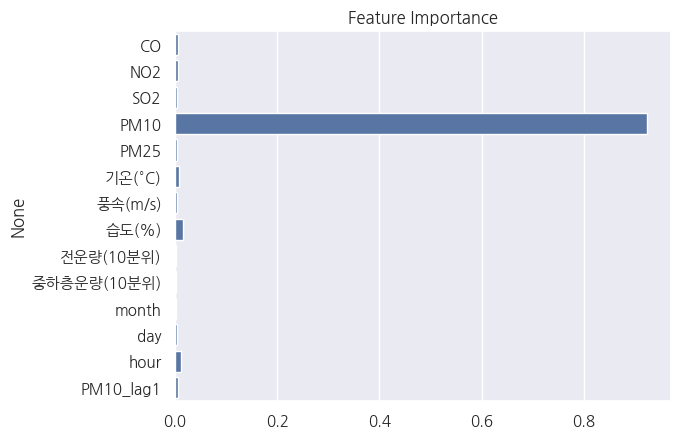

In [ ]:
# feature_importances 시각화

sns.barplot(x=feature_importances, y=train_x.columns)
plt.title('Feature Importance')
plt.show()

In [ ]:
# 모델 학습 진행 하고 성능을 평가하여 출력해 보세요.
# 성능평가는 MSE, R2 Score

from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(train_x, train_y)

y_pred_GB = model.predict(test_x)

print(mean_squared_error(test_y, y_pred_GB))
print(r2_score(test_y, y_pred_GB))

75.39406778997572
0.9008517736219879


In [ ]:
# 학습한 모델을 파일로 저장해보세요.

model_name = 'model_GB.pkl'
joblib.dump(model, path + model_name)


['/content/drive/MyDrive/KT AIVLE/project1/project1/model_GB.pkl']

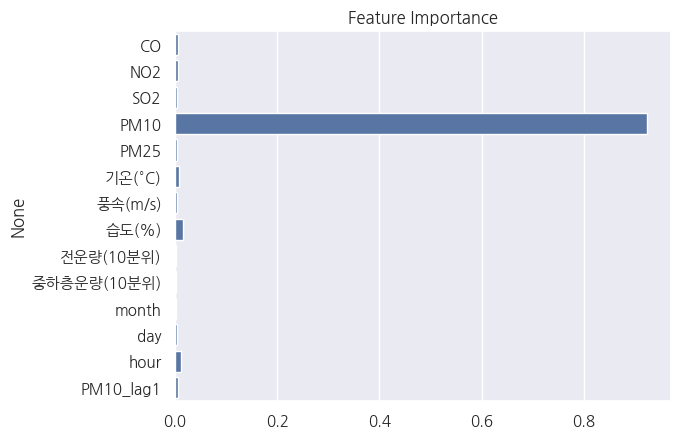

In [ ]:
# 그라디언트부스팅으로 학습한 모델의 feature_importances를 구해보세요.
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.


sns.barplot(x=feature_importances, y=train_x.columns)
plt.title('Feature Importance')
plt.show()


In [ ]:
# 모델 학습 진행 하고 성능을 평가하여 출력해 보세요.
# (예시)xgboost 등

from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(train_x, train_y)

y_pred_XGB = model.predict(test_x)

print(mean_squared_error(test_y, y_pred_XGB))
print(r2_score(test_y, y_pred_XGB))


74.48243632037065
0.9020506297915942


In [ ]:
# 학습한 모델을 파일로 저장해보세요.

model_name = 'model_XGB.pkl'
joblib.dump(model, path + model_name)


['/content/drive/MyDrive/KT AIVLE/project1/project1/model_XGB.pkl']